In [1]:
%matplotlib widget

In [2]:
import numpy as np
from scipy.interpolate import PPoly
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from plotbin.display_pixels import display_pixels 
import pandas as pd
from astropy.io import fits
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from astropy.convolution import Gaussian1DKernel
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection

In [3]:
def Ku03(x):
    # AGN selection based on Kauffman et al. 2003
    return 0.61 / (x - 0.05) + 1.3

def Ke01(x):
    # AGN selection based on Kewley et al. 2001
    return 0.61 / (x - 0.47) + 1.19

def S06(x):
    # AGN selection based on Stasinska et al 2006
    return 0.29 / (x + 0.20) + 0.96

def C10(x):
 # Seyfert–LINER line based on Cid Fernandes et al 2010
    return 1.01*x + 0.48

def inverse_kewley(y):
    return (0.051 + 0.47 * y) / (y - 1.19)

def inverse_kauffmann(y):
    return (0.05 * y + 0.545) / (y - 1.3)

def inverse_stasinska(y):
    return 0.29 / (y - 0.96) - 0.20

def classify_BPT(N2Ha, O3Hb):  # log
    mask = np.zeros(N2Ha.shape[0], dtype=int)
    for i in range(N2Ha.shape[0]):
        x_kewley = inverse_kewley(O3Hb[i])
        x_kauffmann = inverse_kauffmann(O3Hb[i])
        x_stasinska = inverse_stasinska(O3Hb[i])

        if N2Ha[i] < x_stasinska: 
            mask[i] = 1  # SF
        elif N2Ha[i] >= x_stasinska and N2Ha[i] < x_kauffmann:
            mask[i] = 2  # weak composite
        elif N2Ha[i] >= x_kauffmann and N2Ha[i] < x_kewley:
            mask[i] = 3  # strong composite
        elif N2Ha[i] >= x_kewley:
            mask[i] = 4  # AGN
        else:
            mask[i] = np.nan

    mask[O3Hb > 1] = 4  # AGN if OIII/Hb > 1
    return mask

def plotBPT(N2Ha, O3Hb, OIII_HB_err, NII_HA_err):
    mask = classify_BPT(N2Ha, O3Hb)
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(1, 1, 1)
    ax.errorbar(N2Ha[mask == 1], O3Hb[mask == 1], yerr = OIII_HB_err[mask==1], xerr = NII_HA_err[mask==1], color ='blue', linestyle = 'none', markersize = 4, marker = 'o', label = 'SF') 
    ax.errorbar(N2Ha[mask == 2], O3Hb[mask == 2], yerr = OIII_HB_err[mask==2], xerr = NII_HA_err[mask==2], color ='yellow',  linestyle = 'none', markersize = 4, marker = 'o', label = 'Weak composite')
    ax.errorbar(N2Ha[mask == 3], O3Hb[mask == 3], yerr = OIII_HB_err[mask==3], xerr = NII_HA_err[mask==3], color ='orange', linestyle = 'none', markersize = 4, marker = 'o', label = 'Strong composite') 
    ax.errorbar(N2Ha[mask == 4], O3Hb[mask == 4], yerr = OIII_HB_err[mask==4], xerr = NII_HA_err[mask==4], color ='green', linestyle = 'none', markersize = 4, marker = 'o', label = 'AGN') 

    x = np.linspace(-2, 0.04, num=200)
    x1 = np.linspace(-2, 0.457, num=200)
    x2 = np.linspace(-2, -0.25, num=200)
    x3 = np.linspace(-0.49, 5, num=200)
    ax.plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
    ax.plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
    ax.plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
    ax.plot(x3, C10(x3), label = 'C10', color = 'indigo')

    ax.set_ylim(-1, 1)
    ax.set_xlim(-1.5, 1)
    plt.legend()
    plt.show()

def compute_dKauff(x1, y1):  # Distanza dalla curva di Kauffmann
    x = np.linspace(-2, 1.0, 10000)
    distance = np.sqrt((x1 - x)**2 + (y1 - (0.61 / (x - 0.05) + 1.3))**2)
    return np.min(distance)

def compute_dKewley(x1, y1):  # Distanza dalla curva di Kewley
    x = np.linspace(-2, 2, 10000)
    distance = np.sqrt((x1 - x)**2 + (y1 - (0.61 / (x - 0.47) + 1.19))**2)
    return np.min(distance)

def compute_dStasinska(x1, y1):  # Distanza dalla curva di Stasinska
    x = np.linspace(-2, 1, 10000)
    distance = np.sqrt((x1 - x)**2 + (y1 - (0.29 / (x + 0.20) + 0.96))**2)
    return np.min(distance)

def compute_eta(N2Ha, O3Hb):
    """
    Calcola eta con un gradiente più sfumato basato sulla distanza dalle curve.
    
    eta varia da -1 (fortemente SF) a +1 (fortemente AGN)
    Il gradiente è ora continuo e proporzionale alla distanza dalle curve
    anche all'interno di ogni regione del BPT.
    """
    mask = classify_BPT(N2Ha, O3Hb)
    eta = np.zeros(mask.shape[0])

    for i in range(mask.shape[0]):
        d_stasinska = compute_dStasinska(N2Ha[i], O3Hb[i])
        d_kauffmann = compute_dKauff(N2Ha[i], O3Hb[i])
        d_kewley = compute_dKewley(N2Ha[i], O3Hb[i])
        
        if mask[i] == 1:  # Star-forming
            # Varia da -1 (vicino a Stasinska, più SF puro) a valori più alti (lontano, meno SF)
            # Invertiamo: più sei lontano da Stasinska (verso il basso), più sei SF puro
            eta[i] = -0.5 - 0.5 * (1 - np.exp(-d_stasinska * 3))
            
        elif mask[i] == 2:  # Weak composite
            # Varia linearmente da -0.5 (vicino a Stasinska) a 0 (vicino a Kauffmann)
            total_dist = d_stasinska + d_kauffmann
            if total_dist > 0:
                eta[i] = -0.5 + 0.5 * (d_stasinska / total_dist)
            else:
                eta[i] = -0.25
                
        elif mask[i] == 3:  # Strong composite
            # Varia linearmente da 0 (vicino a Kauffmann) a 0.5 (vicino a Kewley)
            total_dist = d_kauffmann + d_kewley
            if total_dist > 0:
                eta[i] = 0.0 + 0.5 * (d_kauffmann / total_dist)
            else:
                eta[i] = 0.25
                
        elif mask[i] == 4:  # AGN
            # Varia da 0.5 (vicino a Kewley) a 1.0 (molto lontano da Kewley)
            # Usa una scala logaritmica per maggiore sensibilità
            eta[i] = 0.5 + 0.5 * (1 - np.exp(-d_kewley * 3))
            
        else:
            eta[i] = np.nan

    eta = np.clip(eta, -1, 1)
    return eta

def plotBPT_gradient(N2Ha, O3Hb, OIII_HB_err, NII_HA_err):
    eta = compute_eta(N2Ha, O3Hb)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1)

    valid = ~np.isnan(eta)
    scat = ax.scatter(N2Ha[valid], O3Hb[valid],c=eta[valid], cmap='jet', vmin=-1, vmax=1, marker='o', edgecolors='black', alpha=1, linewidths=0.4)
    ax.errorbar( N2Ha[valid], O3Hb[valid], yerr=OIII_HB_err[valid], xerr=NII_HA_err[valid], fmt='none', ecolor='black', elinewidth=0.8, alpha=0.4)
    cbar = plt.colorbar(scat, ax=ax)
    cbar_ax = cbar.ax
    cbar_ax.text(0.3, 0.95, r'AGN', rotation=90, fontsize=15, color='white',
                 ha='left', va='center', transform=cbar_ax.transAxes)
    cbar_ax.text(0.3, 0.05, r'SF', rotation=90, fontsize=15, color='white',
                 ha='left', va='center', transform=cbar_ax.transAxes)

    x = np.linspace(-2, 0.04, num=200)
    x1 = np.linspace(-2, 0.457, num=200)
    x2 = np.linspace(-2, -0.25, num=200)
    x3 = np.linspace(-0.49, 5, num=200)
    ax.plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
    ax.plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
    ax.plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
    ax.plot(x3, C10(x3), label = 'C10', color = 'indigo')

    ax.set_ylim(-1.5, 1)
    ax.set_xlim(-1.5, 1)
    ax.set_xticks([-1.5, -1.0, -0.5, 0.0, 0.5, 0.75])
    ax.set_xlabel(r'$\log([\mathrm{NII}]/\mathrm{H}\alpha)$', fontsize=15)
    ax.set_ylabel(r'$\log([\mathrm{OIII}]/\mathrm{H}\beta)$', fontsize=15)
    plt.title('BPT', fontsize=15)
    plt.legend()
    plt.show()

In [4]:
spectra = []

for i in range(1, 21):
    df = pd.read_csv(f"Spectrum_{i}_gas_exp.csv")
    df = df.set_index('Name')
    spectra.append(df)
    
SNR_HA = pd.read_csv("SNR_HA.csv")
SNR_HB = pd.read_csv("SNR_HB.csv") 
SNR_NII_2 = pd.read_csv("SNR_NII_2.csv") 
SNR_OIII_2 = pd.read_csv("SNR_OIII_2.csv") 
SNR_SII_1 = pd.read_csv("SNR_SII_1.csv") 

In [5]:
def error_ratio(err_1, err_2, flux_1, flux_2):
    try:
        e_1 = err_1 / (flux_1 * np.log(10)) if flux_1 != 0 else np.nan
        e_2 = err_2 / (flux_2 * np.log(10)) if flux_2 != 0 else np.nan
        return np.sqrt(e_1**2 + e_2**2)
    except:
        return np.nan

def log_ratio(spectrum):
    OIII_HB = np.log10(spectrum.loc['[OIII]5007', 'Flux']/spectrum.loc['Hbeta', 'Flux'])
    NII_HA = np.log10(spectrum.loc['[NII]6583', 'Flux']/spectrum.loc['Halpha', 'Flux'])
    SII_HA = np.log10(spectrum.loc['[SII]6716', 'Flux']/spectrum.loc['Halpha', 'Flux'])
    #OI_HA = spectrum.loc['[OI]6300', 'Flux']/spectrum.loc['Halpha', 'Flux']
    
    err_OIII_HB = error_ratio(spectrum.loc['[OIII]5007', 'Error_flux'], spectrum.loc['Hbeta', 'Error_flux'], spectrum.loc['[OIII]5007', 'Flux'], spectrum.loc['Hbeta', 'Flux'])
    err_NII_HA = error_ratio(spectrum.loc['[NII]6583', 'Error_flux'], spectrum.loc['Halpha', 'Error_flux'], spectrum.loc['[NII]6583', 'Flux'], spectrum.loc['Halpha', 'Flux'])
    err_SII_HA = error_ratio(spectrum.loc['[SII]6716', 'Error_flux'], spectrum.loc['Halpha', 'Error_flux'], spectrum.loc['[SII]6716', 'Flux'], spectrum.loc['Halpha', 'Flux']) 
    #err_OI_HA = error_ratio(spectrum.loc['[OI]6300', 'Error_flux'], spectrum.loc['Halpha', 'Error_flux'], spectrum.loc['[OI]6300', 'Flux'], spectrum.loc['Halpha', 'Flux']) 
    
    return OIII_HB, NII_HA, SII_HA, err_OIII_HB, err_NII_HA, err_SII_HA

def evaluation_SNR(SNR_HA, SNR_HB, SNR_NII, SNR_SII, SNR_OIII):
    if (SNR_HB < 0) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3): # and (SNR_SII >= 3):
        return True 
    elif (SNR_HB >= 3) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3):# and (SNR_SII >= 3):
        return True 
    else: return False 

Nan: 1
0.414 -1.517 0.325 0.732 -0.649
Nan: 2
7.571 -0.127 1.807 0.238 0.242
Nan: 3
-0.359 -0.819 -0.24 -0.478 -2.445
Nan: 4
1.534 -1.205 1.539 0.407 1.141
Nan: 5
-2.5 -1.753 1.886 2.059 0.219
Nan: 6
0.679 -1.638 0.393 -0.624 0.452
Nan: 7
-2.634 -2.837 1.338 0.505 0.146
Nan: 8
0.231 -1.203 1.444 2.809 -1.917
Nan: 9
-0.967 -3.885 0.921 1.281 1.112
Nan: 10
5.111 -0.619 0.207 0.857 0.169
Nan: 11
33.394 2.502 7.289 17.75 2.619
Nan: 14
9.579 0.116 2.298 3.366 3.664
Nan: 15
13.689 0.957 6.443 0.579 0.647
Nan: 16
-1.128 -1.119 2.114 0.5 -1.261
Nan: 17
-1.07 -1.352 1.413 0.977 0.427
Nan: 18
-1.113 -0.053 0.36 0.595 -0.26
Nan: 19
-0.659 -1.882 0.076 0.15 -1.479
Nan: 20
-0.478 -1.097 0.282 0.399 1.419


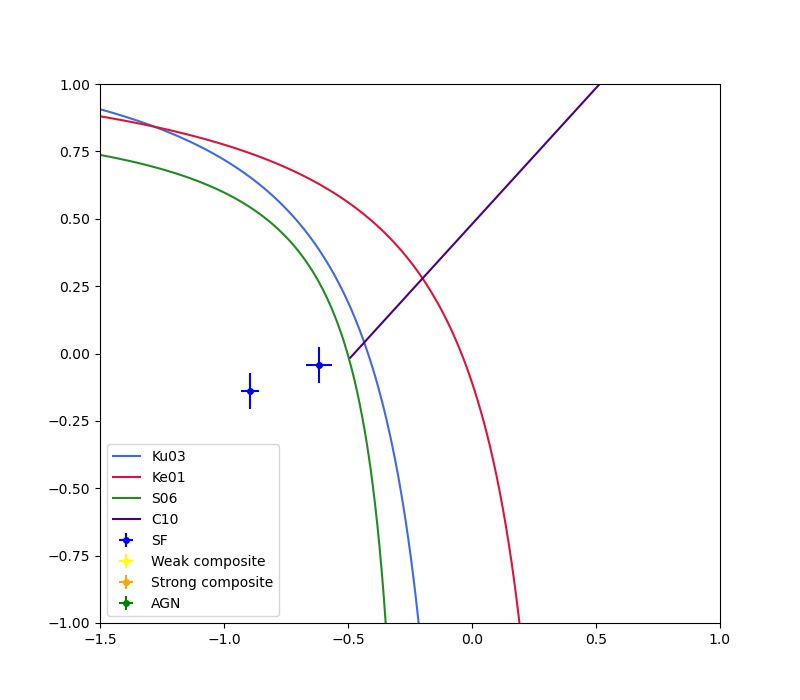

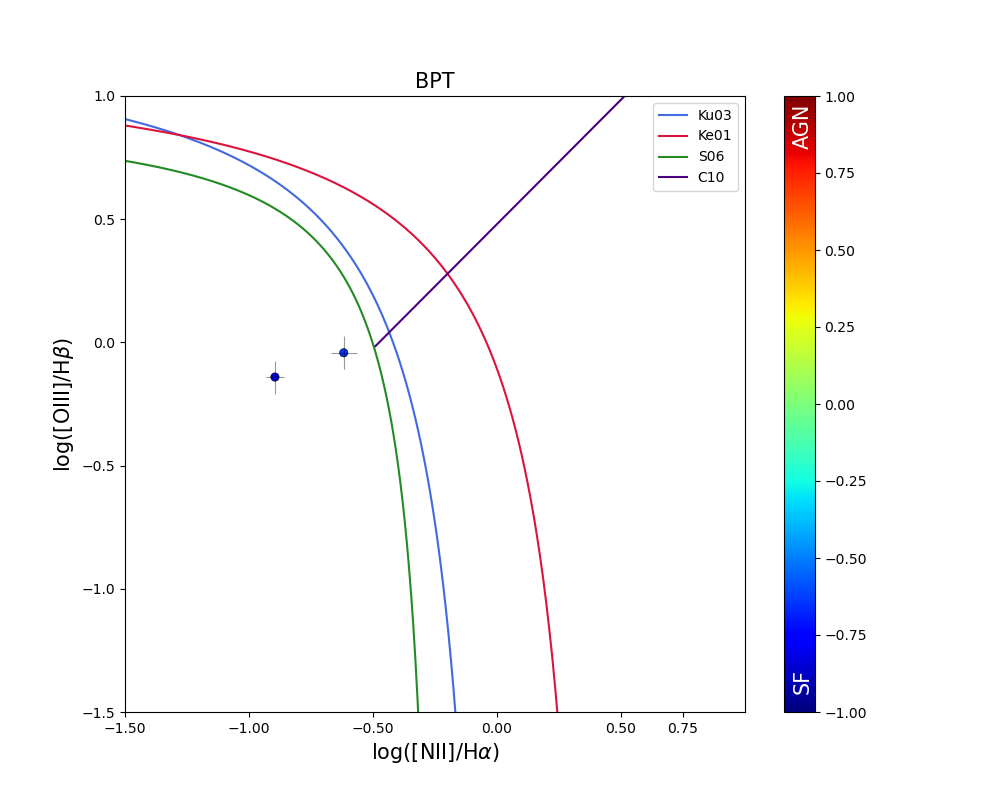

In [6]:
NII_HA =[]
OIII_HB =[]
SII_HA =[]
NII_HA_err =[]
OIII_HB_err =[]
SII_HA_err =[]
for i in range(len(spectra)):
    SNR = evaluation_SNR(SNR_HA['SNR'][i], SNR_HB['SNR'][i], SNR_NII_2['SNR'][i], SNR_SII_1['SNR'][i], SNR_OIII_2['SNR'][i])
    if SNR == True: 
        spectrum = spectra[i]
        oiii_hb, nii_ha, sii_ha, err_oiii_hb, err_nii_ha, err_sii_ha = log_ratio(spectrum)
        if np.isnan(oiii_hb) == False:
            OIII_HB.append(oiii_hb)
            OIII_HB_err.append(err_oiii_hb)
        if np.isnan(sii_ha) == False:
            SII_HA.append(sii_ha)
            SII_HA_err.append(err_sii_ha)
        if np.isnan(nii_ha) == False:    
            NII_HA.append(nii_ha)
            NII_HA_err.append(err_nii_ha)
    
    else: 
        oiii_hb = np.nan
        nii_ha = np.nan
        sii_ha = np.nan
        err_oiii_hb = np.nan
        err_nii_ha = np.nan
        err_sii_ha = np.nan
        NII_HA.append(nii_ha)
        OIII_HB.append(oiii_hb)
        SII_HA.append(sii_ha)
        NII_HA_err.append(err_nii_ha)
        OIII_HB_err.append(err_oiii_hb)
        SII_HA_err.append(err_sii_ha)
        print('Nan:', i+1)
        print(SNR_HA['SNR'][i], SNR_HB['SNR'][i], SNR_NII_2['SNR'][i], SNR_SII_1['SNR'][i], SNR_OIII_2['SNR'][i])
        
OIII_HB_ok = []
SII_HA_ok = []
NII_HA_ok = []
OIII_HB_err_ok = []
SII_HA_err_ok = []
NII_HA_err_ok = []

for i in range(len(spectra)):
    if np.isnan(OIII_HB[i]) == False:
        OIII_HB_ok.append(OIII_HB[i])
        OIII_HB_err_ok.append(OIII_HB_err[i])
    if np.isnan(SII_HA[i]) == False:
        SII_HA_ok.append(SII_HA[i])
        SII_HA_err_ok.append(SII_HA_err[i])
    if np.isnan(NII_HA[i]) == False:
        NII_HA_ok.append(NII_HA[i])
        NII_HA_err_ok.append(NII_HA_err[i])
        
NII_HA_ok = np.array(NII_HA_ok)
OIII_HB_ok = np.array(OIII_HB_ok)
NII_HA_err_ok = np.array(NII_HA_err_ok)
OIII_HB_err_ok = np.array(OIII_HB_err_ok)

plotBPT(NII_HA_ok, OIII_HB_ok, OIII_HB_err_ok, NII_HA_err_ok)

# 4. Diagramma con gradiente continuo
plotBPT_gradient(NII_HA_ok, OIII_HB_ok, OIII_HB_err_ok, NII_HA_err_ok)

In [7]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, params):
    """ Profilo Sérsic 1D centrato in x_0 """
    I_e, r_e, n, x_0 = params
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, params1, params2, params3): #, params4, params5):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, params1) +
        sersic_1d(x_hr, params2) +
        sersic_1d(x_hr, params3) #+
        #sersic_1d(x_hr, params4) +
        #sersic_1d(x_hr, params5)
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def sersic_1d_convolved(x, sigma, params):
    """ Sérsic convoluto con PSF gaussiana """
    I_e, r_e, n, x_0 = params
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, params)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

In [8]:
OIII_HB_ok = []
SII_HA_ok = []
NII_HA_ok = []
OIII_HB_err_ok = []
SII_HA_err_ok = []
NII_HA_err_ok = []
valid_indices = []

for i in range(len(spectra)):
    if np.isnan(OIII_HB[i]) == False and np.isnan(NII_HA[i]) == False:
        OIII_HB_ok.append(OIII_HB[i])
        OIII_HB_err_ok.append(OIII_HB_err[i])
        NII_HA_ok.append(NII_HA[i])
        NII_HA_err_ok.append(NII_HA_err[i])
        valid_indices.append(i)
    
    if np.isnan(SII_HA[i]) == False:
        SII_HA_ok.append(SII_HA[i])
        SII_HA_err_ok.append(SII_HA_err[i])
        
NII_HA_ok = np.array(NII_HA_ok)
OIII_HB_ok = np.array(OIII_HB_ok)
NII_HA_err_ok = np.array(NII_HA_err_ok)
OIII_HB_err_ok = np.array(OIII_HB_err_ok)
valid_indices = np.array(valid_indices)

In [9]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_2/FORS2.2022-01-30T07_40_05.209/UGC-7596_2_MAPPED_FLUX_SCI_LSS_U1.fits") #spectrum
image_data_2 = hdul2[0].data
image_error_2 = hdul2[1].data
image_cut_2 = image_data_2[72:172, 0:1890]
image_error_cut_2 = image_error_2[72:172, 0:1890]
z = 0.00189
l_HA = 6563 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/PSF/Real_seeing_UGC7596.txt")
sigmas = seeing / 2.35

wavelenghts = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
mask_HA = (wavelenghts > l_HA-8)*(wavelenghts < l_HA+8)
image_HA = image_cut_2[:, mask_HA]
image_error_HA = image_error_cut_2[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))
sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_2/FORS2.2022-01-30T07_40_05.209/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
fit = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_2/FORS2.2022-01-30T07_40_05.209/Fit/Halpha_fit.csv", index_col=0)

In [10]:
def plotBPT_gradient_profile(N2Ha, O3Hb, OIII_HB_err, NII_HA_err, spectra_indices):
    """
    spectra_indices: array con gli indici degli spettri validi che corrispondono 
                     ai punti nel BPT (stesso ordine di N2Ha, O3Hb)
    """
    eta = compute_eta(N2Ha, O3Hb)
    
    # Crea figura con due subplot affiancati
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    
    # ===== PRIMO GRAFICO: BPT DIAGRAM =====
    valid = ~np.isnan(eta)
    scat = ax[0].scatter(N2Ha[valid], O3Hb[valid], c=eta[valid], cmap='jet', 
                        vmin=-1, vmax=1, marker='o', edgecolors='black', 
                        alpha=1, linewidths=0.4)
    ax[0].errorbar(N2Ha[valid], O3Hb[valid], yerr=OIII_HB_err[valid], 
                   xerr=NII_HA_err[valid], fmt='none', ecolor='black', 
                   elinewidth=0.8, alpha=0.4)
    
    # Colorbar per il primo grafico
    cbar = plt.colorbar(scat, ax=ax[0])
    cbar_ax = cbar.ax
    cbar_ax.text(0.3, 0.95, r'AGN', rotation=90, fontsize=15, color='white',
                 ha='left', va='center', transform=cbar_ax.transAxes)
    cbar_ax.text(0.3, 0.05, r'SF', rotation=90, fontsize=15, color='white',
                 ha='left', va='center', transform=cbar_ax.transAxes)
    
    # Curve di classificazione
    x = np.linspace(-2, 0.04, num=200)
    x1 = np.linspace(-2, 0.457, num=200)
    x2 = np.linspace(-2, -0.25, num=200)
    x3 = np.linspace(-0.49, 5, num=200)

    ax[0].plot(x, Ku03(x), label='Ku03', color='royalblue')
    ax[0].plot(x1, Ke01(x1), label='Ke01', color='crimson')
    ax[0].plot(x2, S06(x2), label='S06', color='forestgreen')
    ax[0].plot(x3, C10(x3), label = 'C10', color = 'indigo')
    
    # Impostazioni primo grafico
    ax[0].set_ylim(-1., 1.5)
    ax[0].set_xlim(-1.75, 0.5)
    ax[0].set_xticks([-1.5, -1.0, -0.5, 0.0, 0.5, 0.75])
    ax[0].set_xlabel(r'$\log([\mathrm{NII}]/\mathrm{H}\alpha)$', fontsize=15)
    ax[0].set_ylabel(r'$\log([\mathrm{OIII}]/\mathrm{H}\beta)$', fontsize=15)
    ax[0].set_title('BPT Diagram', fontsize=15)
    ax[0].legend(loc='best')
    
    # ===== SECONDO GRAFICO: RADIAL PROFILE =====
    # Modello convolved
    y_fit = model_convolved(x_axes, sigmas[0], fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'])#, fit['Component 4'], fit['Component 5']) #, fit['Component 6'])#, fit['Component 7'])
    
    # Dati osservati
    ax[1].errorbar(x_axes, radial_profile_HA, yerr=radial_profile_error_HA, label='Data', zorder=3)
    
    # Componenti individuali
    colors_comp = ['b', 'g', 'm']#, 'orange', 'chocolate']#, 'dodgerblue']#, 'deeppink']   
    components = ['Component 1', 'Component 2', 'Component 3']#, 'Component 4', 'Component 5']#, 'Component 6']#, 'Component 7']
    
    for i, comp_name in enumerate(components):
        color = colors_comp[i]
        y_comp = sersic_1d_convolved(x_axes, sigmas[0], np.array(fit[comp_name]))
        ax[1].plot(x_axes, y_comp, '--', color=color, label=f'Sérsic {i+1}')
    
    # Bande colorate in base a eta
    # Crea un dizionario che mappa l'indice dello spettro al valore di eta
    cmap = cm.get_cmap('jet')
    norm = mcolors.Normalize(vmin=-1, vmax=1)
    
    valid = ~np.isnan(eta)
    eta_dict = {}
    for idx, spectrum_idx in enumerate(spectra_indices[valid]):
        eta_dict[spectrum_idx] = eta[valid][idx]
    
    # Crea array con le posizioni centrali degli spettri e i loro valori eta
    spectrum_positions = []
    eta_values = []
    for spectrum_idx in sorted(eta_dict.keys()):
        center_position = spectrum_idx * 5 + 2.5  # centro della fascia di 5 pixel
        spectrum_positions.append(center_position)
        eta_values.append(eta_dict[spectrum_idx])
    
    # Interpolazione smooth solo per spettri validi
    from scipy.interpolate import interp1d
    eta_interp = None
    if len(spectrum_positions) >= 2:
        # Interpolazione lineare per le regioni valide
        eta_interp = interp1d(spectrum_positions, eta_values, kind='linear', 
                             bounds_error=False, fill_value=np.nan)
    
    # Crea array di colori per ogni punto del profilo radiale
    colors_array = []
    for i in range(len(x_axes)):
        spectrum_idx = int(i / 5)
        
        if spectrum_idx in eta_dict:
            # Spettro valido: usa interpolazione smooth
            if eta_interp is not None:
                eta_value = eta_interp(x_axes[i])
                if not np.isnan(eta_value):
                    colors_array.append(cmap(norm(eta_value)))
                else:
                    colors_array.append(cmap(norm(eta_dict[spectrum_idx])))
            else:
                # Solo un punto valido, usa il valore diretto
                colors_array.append(cmap(norm(eta_dict[spectrum_idx])))
        else:
            # Spettro non valido: grigio
            colors_array.append('gray')

    # Crea segmenti di linea
    points = np.array([x_axes, y_fit]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    # Crea LineCollection con colori variabili
    lc = LineCollection(segments, colors=colors_array[:-1], linewidth=3, zorder=5)
    ax[1].add_collection(lc)
    
    # Aggiungi linee verticali tratteggiate per delimitare le regioni degli spettri
    for i in range(len(spectra)):
        x_pos = i * 5
        ax[1].axvline(x_pos, linestyle=':', linewidth=0.8, alpha=0.8, color='gray')
    ax[1].axvline(100, linestyle=':', linewidth=0.8, alpha=0.8, color='gray')
    # Impostazioni secondo grafico
    ax[1].set_xlabel('Radius [pixels]', fontsize=12)
    ax[1].set_ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]', fontsize=12)
    ax[1].set_title(r'Radial Profile H$\alpha$', fontsize=15)
    ax[1].grid(True, alpha=0.3)
    ax[1].legend(loc='best')
    plt.suptitle('UGC7596 (2)', fontsize = 20)
    
    plt.tight_layout()
    plt.show()
    plt.savefig('BPT_grad_profile_UGC7596_2')

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_880\3279374285.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('jet')


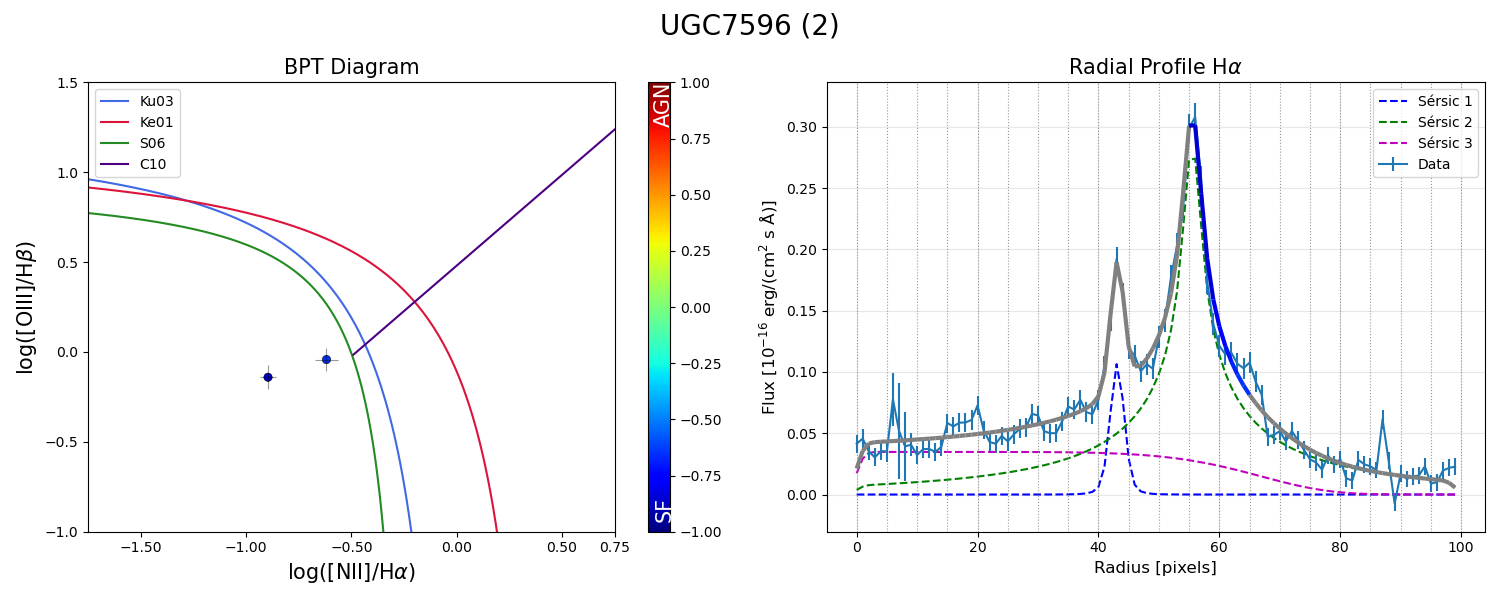

In [11]:
plotBPT_gradient_profile(NII_HA_ok, OIII_HB_ok, OIII_HB_err_ok, NII_HA_err_ok, valid_indices)